In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/CustomerIntelligence/sample_tickets.csv')
display(df.head())

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [ ]:
print(df.isnull().sum())

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64


In [ ]:

import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# -------------------------------
# Load Dataset
# -------------------------------
# Example:
# df = pd.read_csv("tickets.csv")

# -------------------------------
# Encode Target Variable
# -------------------------------
label_encoder = LabelEncoder()
df["Ticket Type"] = label_encoder.fit_transform(df["Ticket Type"])

# -------------------------------
# Feature Engineering Function
# -------------------------------
def combine_text(df):
    df = df.copy()

    # Combine Subject and Description
    df["Combined_Text"] = (
        df["Ticket Subject"].fillna("") +
        " " +
        df["Ticket Description"].fillna("")
    )

    return df

text_combiner = FunctionTransformer(combine_text, validate=False)

# -------------------------------
# Preprocessor
# -------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(stop_words="english", max_features=5000),
            "Combined_Text",
        )
    ],
    remainder="drop"
)



In [ ]:
# -------------------------------
# Complete Pipeline
# -------------------------------
pipeline = Pipeline([
    ("combine_text", text_combiner),
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=5000, random_state=42))
])

In [ ]:
# -------------------------------
# Features and Target
# -------------------------------
X = df[["Ticket Subject", "Ticket Description"]]
y = df["Ticket Type"]

# -------------------------------
# Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:

# -------------------------------
# Train Model
# -------------------------------
pipeline.fit(X_train, y_train)

# -------------------------------
# Prediction
# -------------------------------
y_pred = pipeline.predict(X_test)

# -------------------------------
# Evaluation
# -------------------------------
print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.20484061393152303


In [ ]:
!pip install mlflow


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 99.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13

2026/07/10 17:30:58 INFO mlflow.tracking.fluent: Experiment with name 'CustomerIntelligence_Experiment' does not exist. Creating a new experiment.


EVALUATION METRICS
Precision (weighted): 0.2047
Recall (weighted):    0.2048
F1-Score (weighted):  0.2046

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.18      0.17      0.17       327
           1       0.19      0.20      0.20       339
           2       0.22      0.22      0.22       328
           3       0.21      0.21      0.21       351
           4       0.22      0.23      0.22       349

    accuracy                           0.20      1694
   macro avg       0.20      0.20      0.20      1694
weighted avg       0.20      0.20      0.20      1694


CONFUSION MATRIX (Raw Counts)
[[55 63 70 70 69]
 [64 69 61 77 68]
 [54 62 71 66 75]
 [69 81 56 73 72]
 [62 82 59 67 79]]

MLflow run finished. Metrics and artifacts logged.


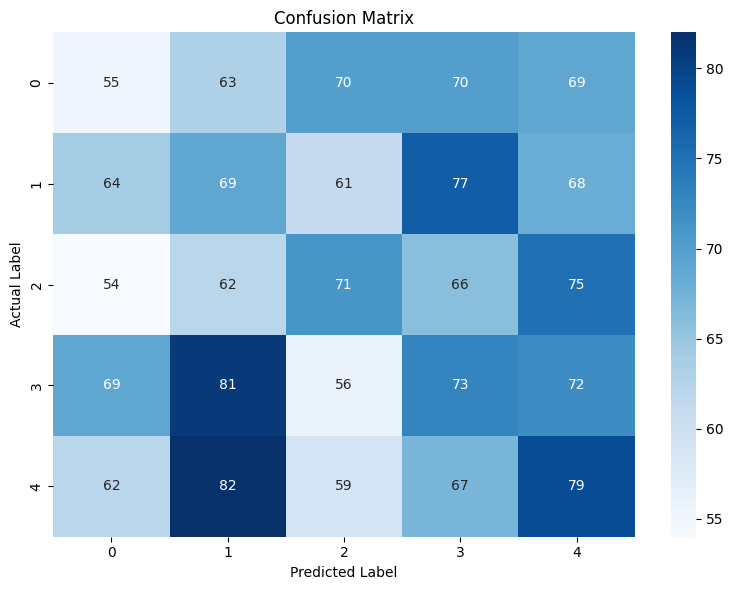

In [ ]:
import mlflow
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import tempfile
import os

# -----------------------------------------------------------------
# Assuming you already have these from your pipeline:
#   - y_test        (true labels)
#   - y_pred        (predictions from pipeline.predict(X_test))
#   - label_encoder (if you encoded your target labels)
# -----------------------------------------------------------------
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true" # Allow filesystem tracking backend
mlflow.set_tracking_uri("/content/drive/MyDrive/CustomerIntelligence/mlruns")
# Start an MLflow run
mlflow.set_experiment("CustomerIntelligence_Experiment")
with mlflow.start_run(run_name="logistic_reg_classification_baseline"):
    # Log parameters (anything that might be relevant)
    mlflow.log_param("average_type", "weighted")
    mlflow.log_param("has_label_encoder", "label_encoder" in locals())

    # 1. Calculate Precision, Recall, and F1 Score
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print("="*50)
    print("EVALUATION METRICS")
    print("="*50)
    print(f"Precision (weighted): {precision:.4f}")
    print(f"Recall (weighted):    {recall:.4f}")
    print(f"F1-Score (weighted):  {f1:.4f}")

    # Log metrics to MLflow
    mlflow.log_metric ("accuracy",accuracy)
    mlflow.log_metric("precision_weighted", precision)
    mlflow.log_metric("recall_weighted", recall)
    mlflow.log_metric("f1_weighted", f1)

    # 2. Classification Report (gives precision/recall/f1 per class)
    print("\n" + "="*50)
    print("DETAILED CLASSIFICATION REPORT")
    print("="*50)
    report = classification_report(y_test, y_pred)
    print(report)

    # Log the classification report as a text artifact
    with tempfile.NamedTemporaryFile(mode="w", suffix=".txt", delete=False) as f:
        f.write(report)
        report_path = f.name
    mlflow.log_artifact(report_path, artifact_path="classification_report")
    os.remove(report_path)  # clean up temp file

    # 3. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\n" + "="*50)
    print("CONFUSION MATRIX (Raw Counts)")
    print("="*50)
    print(cm)

    # 4. Visualize Confusion Matrix with Seaborn/Matplotlib
    class_names = None
    if 'label_encoder' in locals():
        class_names = label_encoder.classes_
    else:
        class_names = sorted(set(y_test))

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()

    # Save the confusion matrix plot as a temporary image and log it
    with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmp_file:
        plt.savefig(tmp_file.name, dpi=150, bbox_inches='tight')
        cm_plot_path = tmp_file.name
    os.remove(cm_plot_path)

    # Optionally, also log the raw confusion matrix as a CSV or JSON artifact
    # (you could use mlflow.log_table or log_dict if you prefer)

    # If you have a trained model, you could log it with mlflow.sklearn.log_model()
    # e.g., mlflow.sklearn.log_model(pipeline, "model")

    print("\nMLflow run finished. Metrics and artifacts logged.")


#MultiNomialNB model

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

# -------------------------------
# Complete Pipeline
# -------------------------------
Nbpipeline = Pipeline([
    ("combine_text", text_combiner),
    ("preprocessor", preprocessor),
    ('clf', MultinomialNB())
])

In [ ]:

# -------------------------------
# Train Model
# -------------------------------
pipeline.fit(X_train, y_train)

# -------------------------------
# Prediction
# -------------------------------
y_pred = pipeline.predict(X_test)

# -------------------------------
# Evaluation
# -------------------------------
print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.20484061393152303


EVALUATION METRICS
Precision (weighted): 0.2047
Recall (weighted):    0.2048
F1-Score (weighted):  0.2046

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.18      0.17      0.17       327
           1       0.19      0.20      0.20       339
           2       0.22      0.22      0.22       328
           3       0.21      0.21      0.21       351
           4       0.22      0.23      0.22       349

    accuracy                           0.20      1694
   macro avg       0.20      0.20      0.20      1694
weighted avg       0.20      0.20      0.20      1694


CONFUSION MATRIX (Raw Counts)
[[55 63 70 70 69]
 [64 69 61 77 68]
 [54 62 71 66 75]
 [69 81 56 73 72]
 [62 82 59 67 79]]

MLflow run finished. Metrics and artifacts logged.


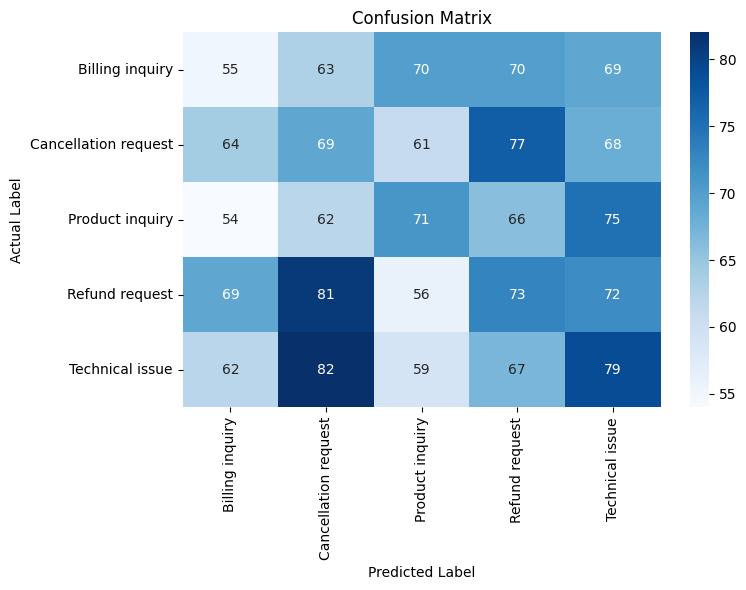

In [ ]:
import mlflow
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import tempfile
import os

# -----------------------------------------------------------------
# Assuming you already have these from your pipeline:
#   - y_test        (true labels)
#   - y_pred        (predictions from pipeline.predict(X_test))
#   - label_encoder (if you encoded your target labels)
# -----------------------------------------------------------------
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true" # Allow filesystem tracking backend
mlflow.set_tracking_uri("/content/drive/MyDrive/CustomerIntelligence/mlruns")
# Start an MLflow run
mlflow.set_experiment("CustomerIntelligence_Experiment")
with mlflow.start_run(run_name="MultiNominalNB_classification_baseline"):
    # Log parameters (anything that might be relevant)
    mlflow.log_param("average_type", "weighted")
    mlflow.log_param("has_label_encoder", "label_encoder" in locals())

    # 1. Calculate Precision, Recall, and F1 Score
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print("="*50)
    print("EVALUATION METRICS")
    print("="*50)
    print(f"Precision (weighted): {precision:.4f}")
    print(f"Recall (weighted):    {recall:.4f}")
    print(f"F1-Score (weighted):  {f1:.4f}")

    # Log metrics to MLflow
    mlflow.log_metric ("accuracy",accuracy)
    mlflow.log_metric("precision_weighted", precision)
    mlflow.log_metric("recall_weighted", recall)
    mlflow.log_metric("f1_weighted", f1)

    # 2. Classification Report (gives precision/recall/f1 per class)
    print("\n" + "="*50)
    print("DETAILED CLASSIFICATION REPORT")
    print("="*50)
    report = classification_report(y_test, y_pred)
    print(report)

    # Log the classification report as a text artifact
    with tempfile.NamedTemporaryFile(mode="w", suffix=".txt", delete=False) as f:
        f.write(report)
        report_path = f.name
    mlflow.log_artifact(report_path, artifact_path="classification_report")
    os.remove(report_path)  # clean up temp file

    # 3. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\n" + "="*50)
    print("CONFUSION MATRIX (Raw Counts)")
    print("="*50)
    print(cm)

    # 4. Visualize Confusion Matrix with Seaborn/Matplotlib
    class_names = None
    if 'label_encoder' in locals():
        class_names = label_encoder.classes_
    else:
        class_names = sorted(set(y_test))

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()

    # Save the confusion matrix plot as a temporary image and log it
    with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmp_file:
        plt.savefig(tmp_file.name, dpi=150, bbox_inches='tight')
        cm_plot_path = tmp_file.name
    os.remove(cm_plot_path)

    # Optionally, also log the raw confusion matrix as a CSV or JSON artifact
    # (you could use mlflow.log_table or log_dict if you prefer)

    # If you have a trained model, you could log it with mlflow.sklearn.log_model()
    # e.g., mlflow.sklearn.log_model(pipeline, "model")

    print("\nMLflow run finished. Metrics and artifacts logged.")
